In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [177]:
def multi_plot(data1, data2,title, labels, n_threads):
    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    group_positions = []  # Per le etichette centrate

    color_map = ["peachpuff", "orange"]

    for i in range(len(n_threads)):
        boxes.extend([data1[i], data2[i]])
        colors.extend(color_map)
        # Ogni gruppo di 4 box parte alla posizione 4*i+1 → il centro è +1.5
        group_center = 2 * i + 1.5
        group_positions.append(group_center)

    # Crea boxplot
    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)

    # Colori per ogni box
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # Etichette centrate per ogni gruppo
    ax.set_xticks(group_positions)
    ax.set_xticklabels([str(n) for n in n_threads])

    # Etichette e titolo
    ax.set_ylabel('Microseconds')
    ax.set_xlabel('n_threads')
    ax.set_title(title, loc='left')

    # Legenda (usiamo solo il primo gruppo per i colori)
    legend_handles = [bplot["boxes"][i] for i in range(2)]
    ax.legend(legend_handles, labels, loc='upper right')

    # Mediane in rosso
    for median in bplot['medians']:
        median.set_color('red')

    plt.figtext(0.54, 0.98, f"threadpool: size_queue({size_queue})\nsetup: number_total_job({n_elems}), n_unitary_operation_in_single_job({n_body_function*4})\nruns: {n_runs}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

    plt.tight_layout()
    plt.show()

In [225]:
#parametri
#settare manualmente uguali a quelli usati in cluster
n_runs = 50
n_threads = [4,7]  #lista in send_steal_bilanciati.sh !
size_queue = 100
n_body_function = 10000 #cicli in singoli job
n_elems = 150 #job totali


In [252]:
#carica dati da .txt
dati_Round_Random = []
dati_Round_Mostbusy = []

for i,th in enumerate(n_threads):
    dati_Round_Random.append(np.genfromtxt("test_sendRound_stealRandom_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_Round_Mostbusy.append(np.genfromtxt("test_sendRound_stealMostbusy_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

In [253]:
#carica dati da .txt
dati_Random = []
dati_Mostbusy = []

for i,th in enumerate(n_threads):
    dati_Random.append(np.genfromtxt("test_Random_unometa_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])
    dati_Mostbusy.append(np.genfromtxt("test_Mostbusy_unometa_numthread"+str(th)+".txt",delimiter=',',dtype=int)[:-1])

In [254]:
n_runs = len(dati_Round_Random[0])

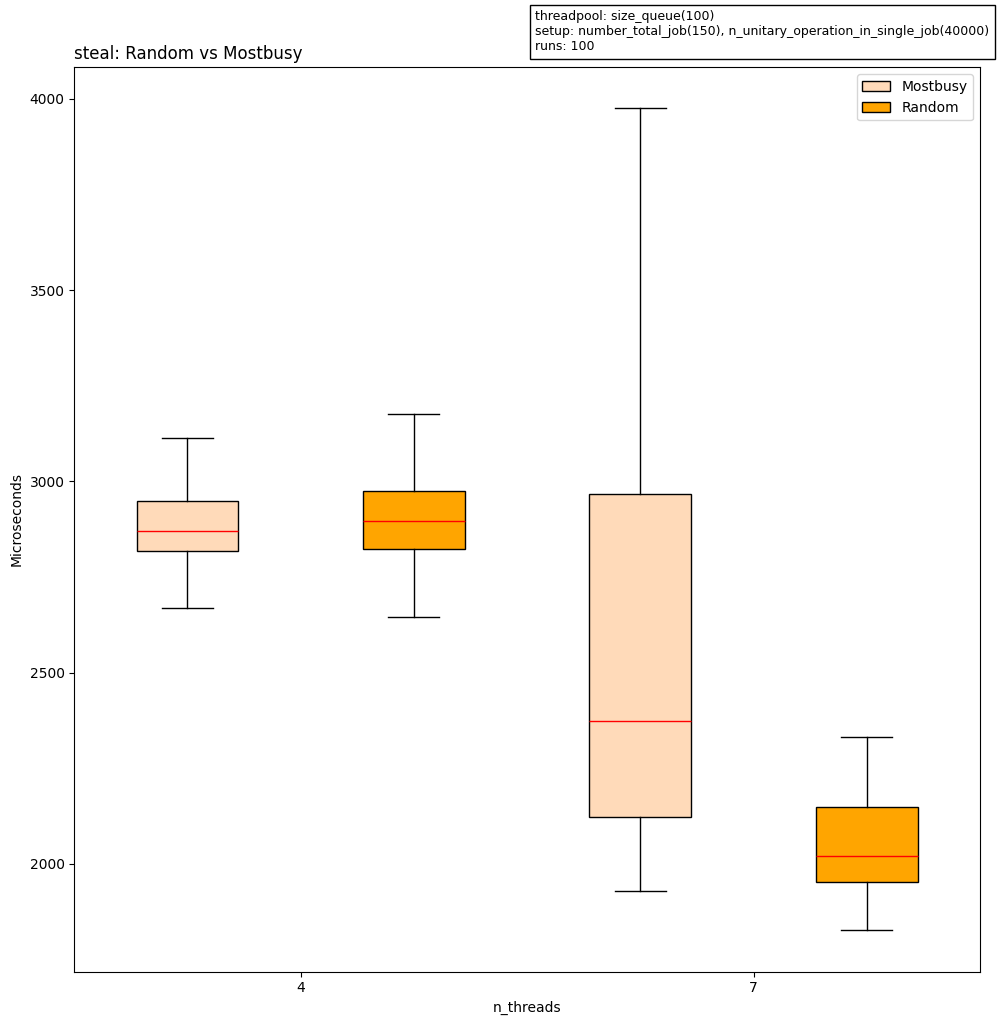

In [255]:
label = ["Mostbusy","Random"]
multi_plot(dati_Round_Mostbusy,dati_Round_Random,"steal: Random vs Mostbusy",label,n_threads)

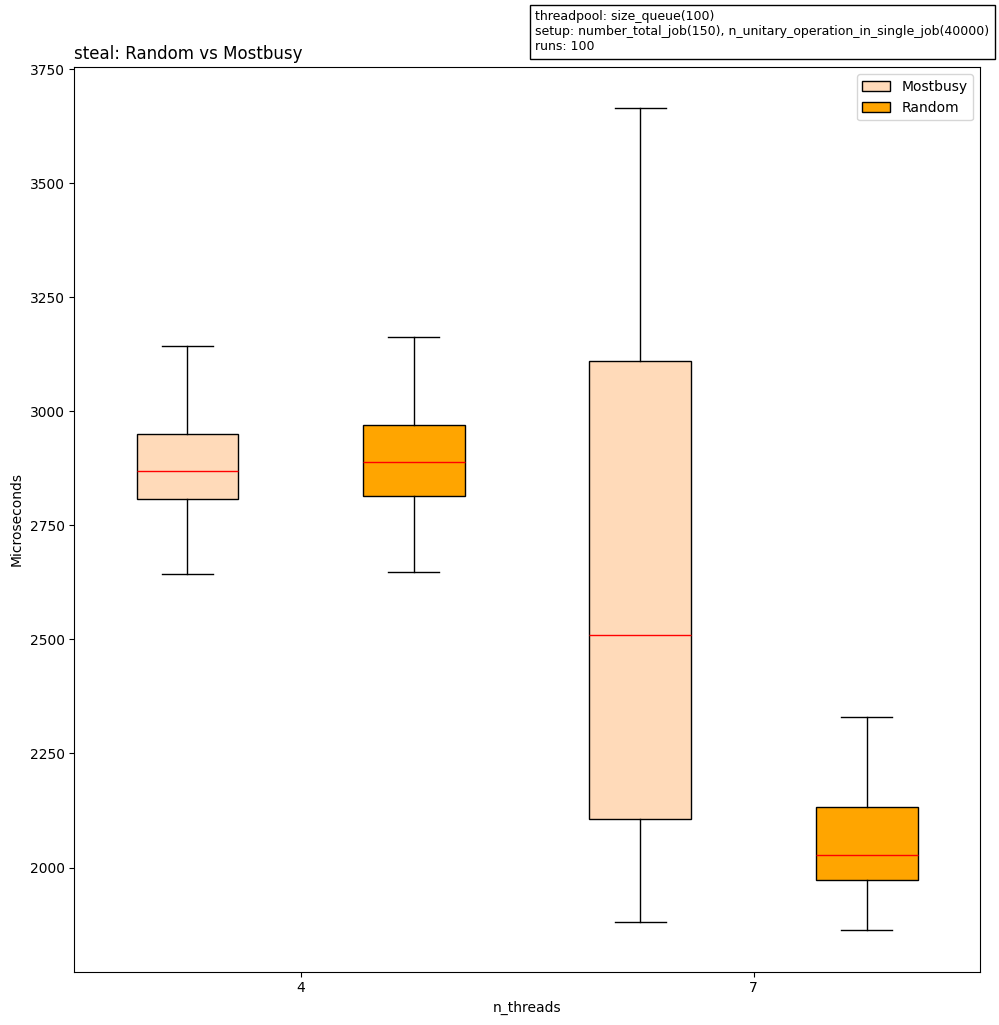

In [256]:
#### uno meta
label = ["Mostbusy","Random"]
multi_plot(dati_Mostbusy,dati_Random,"steal: Random vs Mostbusy",label,n_threads)